# 🌲 Isolation Forest — Anomali Tespiti

**Isolation Forest**, anormal noktaları **erken izole etme** prensibine dayanan bir anomali tespit algoritmasıdır.  
Fikir şudur: **Anormal noktalar azdır ve diğerlerinden uzak durur** → rastgele bölmelerle çabuk yalnız kalırlar.

---

### 🧠 Temel Sezgi

Bir ormanda rastgele çizgiler çektiğini düşün:
- **Normal nokta** → kalabalık bölgede, izole edilmesi çok bölme gerektirir (derin ağaç)
- **Anormal nokta** → ıssız bölgede, az bölmeyle hemen izole edilir (sığ ağaç)

```
Normal:   ●●●●●●●●   → derin ağaç (izole etmek zor)
Anormal:  ●          → sığ ağaç  (izole etmek kolay)
```

---

### 📌 Kullanım Senaryoları
- Kredi kartı dolandırıcılığı tespiti
- Siber saldırı (intrusion detection)
- Sensör verisi anomali tespiti (IoT)
- Tıbbi veri aykırı değer analizi

---

## 📦 1. Kütüphanelerin İçe Aktarılması

In [1]:
# numpy: sayısal hesaplamalar, dizi ve matris işlemleri
import numpy as np

# matplotlib: 2D grafik ve görselleştirme
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec  # esnek alt grafik düzeni

# sklearn — makine öğrenmesi araçları
from sklearn.ensemble import IsolationForest        # ana modelimiz
from sklearn.preprocessing import StandardScaler    # özellik ölçekleme
from sklearn.datasets import make_blobs             # yapay veri üretici
from sklearn.metrics import (classification_report, # detaylı metrik raporu
                             confusion_matrix,       # karmaşıklık matrisi
                             roc_auc_score)          # ROC-AUC skoru

print("✅ Tüm kütüphaneler başarıyla yüklendi.")

✅ Tüm kütüphaneler başarıyla yüklendi.


## 🗂️ 2. Veri Üretimi

Gerçekçi bir senaryo: **üretim hattı sensör verileri**  
- Eğitim: yalnızca normal üretim ölçümleri  
- Test: normal + arızalı makine ölçümleri (karışık)

In [2]:
# Tekrar üretilebilirlik için rastgele tohum
np.random.seed(42)

# ─── EĞİTİM VERİSİ — Yalnızca Normal ───────────────────────────────────────
# İki ayrı küme: farklı çalışma koşullarındaki normal sensör okumalar
# make_blobs: Gauss (normal) dağılımlı kümeler üretir
X_cluster1, _ = make_blobs(
    n_samples=200,
    centers=[[2, 2]],    # 1. küme merkezi: (2, 2)
    cluster_std=0.6,     # standart sapma: noktaların yayılma genişliği
    random_state=42
)
X_cluster2, _ = make_blobs(
    n_samples=150,
    centers=[[-2, -2]],  # 2. küme merkezi: (-2, -2)
    cluster_std=0.5,
    random_state=42
)

# İki normal kümeyi birleştir: toplam 350 normal eğitim noktası
X_train = np.vstack([X_cluster1, X_cluster2])  # vstack: satır bazında yığma

# ─── TEST VERİSİ — Normal + Anormal ─────────────────────────────────────────
# Normal test noktaları (eğitimdekiyle aynı dağılım)
X_test_n1, _ = make_blobs(n_samples=60, centers=[[2, 2]],   cluster_std=0.6, random_state=7)
X_test_n2, _ = make_blobs(n_samples=40, centers=[[-2, -2]], cluster_std=0.5, random_state=7)
X_test_normal = np.vstack([X_test_n1, X_test_n2])  # 100 normal nokta

# Anormal test noktaları: geniş alanda rastgele dağılmış
# uniform: minimum ve maksimum arasında eşit olasılıklı dağılım
X_test_anomaly = np.random.uniform(low=-6, high=6, size=(30, 2))  # 30 anomali

# Tüm test verisi: normal + anormal birleştirildi
X_test = np.vstack([X_test_normal, X_test_anomaly])

# Gerçek etiketler (modele verilmeyecek, sadece değerlendirme için)
# Isolation Forest kuralı: +1 = normal (inlier), -1 = anormal (outlier)
y_true = np.array([1] * len(X_test_normal) + [-1] * len(X_test_anomaly))

print(f"Eğitim seti    : {X_train.shape}  → {len(X_train)} normal nokta (2 küme)")
print(f"Test  seti     : {X_test.shape}  → {len(X_test_normal)} normal + {len(X_test_anomaly)} anormal")
print(f"Anomali oranı  : %{len(X_test_anomaly)/len(X_test)*100:.1f}")

Eğitim seti    : (350, 2)  → 350 normal nokta (2 küme)
Test  seti     : (130, 2)  → 100 normal + 30 anormal
Anomali oranı  : %23.1


## 📊 3. Ham Veri Görselleştirmesi

Modeli eğitmeden önce veriyi görselleştirelim.

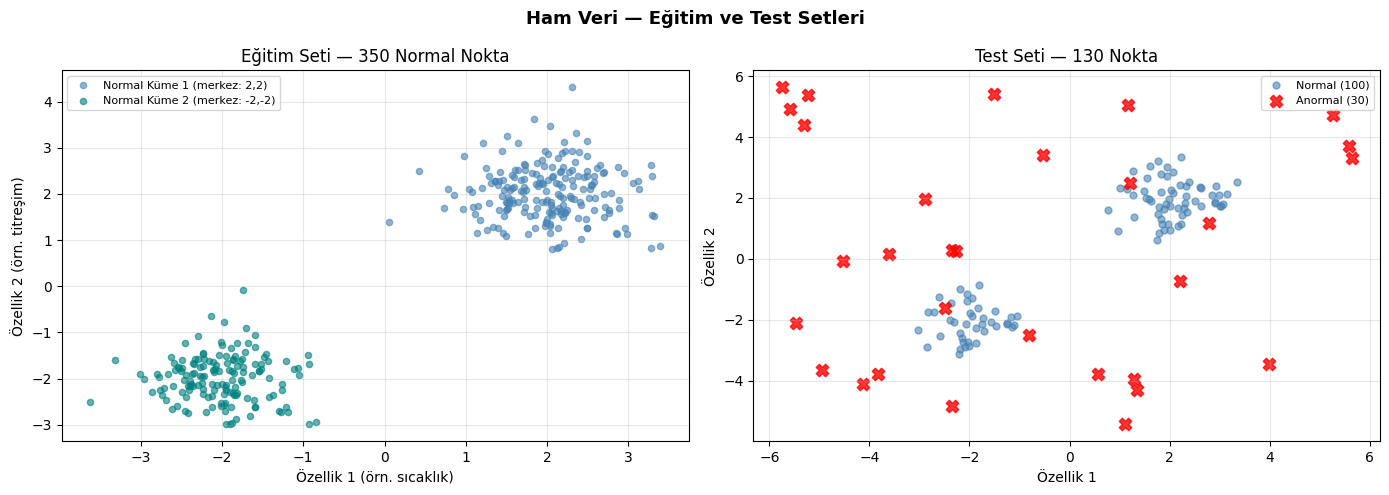

📸 ham_veri.png kaydedildi


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Ham Veri — Eğitim ve Test Setleri', fontsize=13, fontweight='bold')

# ── Sol panel: Eğitim verisi ──────────────────────────────────────────────
ax = axes[0]
ax.scatter(X_cluster1[:, 0], X_cluster1[:, 1],
           c='steelblue', s=20, alpha=0.6, label='Normal Küme 1 (merkez: 2,2)')
ax.scatter(X_cluster2[:, 0], X_cluster2[:, 1],
           c='teal', s=20, alpha=0.6, label='Normal Küme 2 (merkez: -2,-2)')
ax.set_title(f'Eğitim Seti — {len(X_train)} Normal Nokta')
ax.set_xlabel('Özellik 1 (örn. sıcaklık)')
ax.set_ylabel('Özellik 2 (örn. titreşim)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Sağ panel: Test verisi (etiketli) ─────────────────────────────────────
ax = axes[1]
ax.scatter(X_test_normal[:, 0], X_test_normal[:, 1],
           c='steelblue', s=25, alpha=0.6, label=f'Normal ({len(X_test_normal)})')
ax.scatter(X_test_anomaly[:, 0], X_test_anomaly[:, 1],
           c='red', marker='X', s=80, alpha=0.8, label=f'Anormal ({len(X_test_anomaly)})')
ax.set_title(f'Test Seti — {len(X_test)} Nokta')
ax.set_xlabel('Özellik 1')
ax.set_ylabel('Özellik 2')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ham_veri.png', dpi=150, bbox_inches='tight')
plt.show()
print("📸 ham_veri.png kaydedildi")

## ⚖️ 4. Özellik Ölçekleme

`StandardScaler`: her özelliği **ortalama=0, standart sapma=1** yaparak ölçekler.

> **Not:** Isolation Forest ağaç tabanlı olduğundan ölçeklemeye One-Class SVM kadar duyarlı değildir.  
> Yine de tutarlılık ve iyi pratik için ölçekleme yapıyoruz.

In [4]:
scaler = StandardScaler()

# fit_transform: eğitim verisinden ortalama/std öğren VE dönüştür
X_train_scaled = scaler.fit_transform(X_train)

# transform: sadece dönüştür — scaler'ı test verisiyle yeniden fit ETME!
# (Data leakage: test verisi bilgisinin eğitime sızmasını önler)
X_test_scaled = scaler.transform(X_test)

print(f"Eğitim — Ortalama : {X_train_scaled.mean(axis=0).round(6)}  (≈ 0 olmalı)")
print(f"Eğitim — Std Dev  : {X_train_scaled.std(axis=0).round(6)}  (≈ 1 olmalı)")
print("\n✅ Ölçekleme tamamlandı.")

Eğitim — Ortalama : [-0.  0.]  (≈ 0 olmalı)
Eğitim — Std Dev  : [1. 1.]  (≈ 1 olmalı)

✅ Ölçekleme tamamlandı.


## 🌲 5. Isolation Forest — Algoritma Mantığı

### Nasıl Çalışır?

1. **Rastgele Bölme Ağacı (iTrees)** oluşturur:  
   - Rastgele bir özellik seç  
   - O özelliğin min–max aralığında rastgele bir eşik değeri seç  
   - Veriyi ikiye böl, derinleştir

2. **İzolasyon Derinliği** ölçülür:  
   - Bir nokta kaç adımda yalnız kalıyor? → **Anomali Skoru**  
   - Az adım = sığ ağaç = **anomali**  
   - Çok adım = derin ağaç = **normal**

3. **Orman** = `n_estimators` adet iTrees'in ortalaması

| Hiperparametre | Açıklama | Tipik Değer |
|---|---|---|
| `n_estimators` | Ağaç sayısı | 100–200 |
| `contamination` | Beklenen anomali oranı | 0.05–0.20 |
| `max_samples` | Her ağaç için örneklem sayısı | `'auto'` = min(256, n) |
| `max_features` | Her bölmede kullanılan özellik sayısı | 1.0 (tümü) |

In [5]:
# ─── Isolation Forest Modeli ─────────────────────────────────────────────────
model = IsolationForest(
    n_estimators=200,      # Ormandaki ağaç sayısı
                           # Daha fazla ağaç = daha kararlı tahminler, daha yavaş
                           # 100-200 genellikle yeterlidir

    contamination=0.10,    # Verideki beklenen anomali oranı (%10)
                           # Bu değer karar eşiğini (threshold) belirler
                           # Gerçek anomali oranını bilmiyorsak 'auto' kullanılabilir

    max_samples='auto',    # Her ağaç için alt örneklem boyutu
                           # 'auto' → min(256, n_samples)
                           # Küçük örneklem = hızlı eğitim, yeterli çeşitlilik

    max_features=1.0,      # Her bölmede kullanılacak özellik oranı (1.0 = tümü)
                           # 0.5 → her bölmede özelliklerin yarısını kullan

    random_state=42        # Tekrar üretilebilirlik için
)

print("✅ Isolation Forest modeli oluşturuldu:")
print(f"   Ağaç sayısı      : {model.n_estimators}")
print(f"   Contamination    : {model.contamination}")
print(f"   Max samples      : {model.max_samples}")

✅ Isolation Forest modeli oluşturuldu:
   Ağaç sayısı      : 200
   Contamination    : 0.1
   Max samples      : auto


## 🏋️ 6. Modeli Eğitme

> One-Class SVM gibi, Isolation Forest da **yalnızca normal veriyle** eğitilir.  
> Etiket `(y)` verilmez → **gözetimsiz (unsupervised)** öğrenme.

In [6]:
# fit(): 200 adet rastgele izolasyon ağacı eğitir
# Sadece X_train_scaled görür — anormal veri GÖRMEZ
model.fit(X_train_scaled)

# Eğitim verisi üzerinde tahmin (kontrol amaçlı)
train_preds = model.predict(X_train_scaled)
# predict() döndürür: +1 = normal (inlier), -1 = anormal (outlier)

n_inliers  = (train_preds ==  1).sum()
n_outliers = (train_preds == -1).sum()

print(f"✅ Model eğitildi — {len(X_train_scaled)} örnekle, {model.n_estimators} ağaç")
print(f"\nEğitim verisi üzerindeki sonuçlar:")
print(f"  Normal  (+1): {n_inliers}")
print(f"  Anormal (-1): {n_outliers}  ← contamination={model.contamination} → beklenen ≈ {int(len(X_train)*model.contamination)}")

✅ Model eğitildi — 350 örnekle, 200 ağaç

Eğitim verisi üzerindeki sonuçlar:
  Normal  (+1): 315
  Anormal (-1): 35  ← contamination=0.1 → beklenen ≈ 35


## 🔮 7. Test Verisi Üzerinde Tahmin ve Anomali Skorları

Isolation Forest iki tür çıktı üretir:
- `predict()` → ikili karar: **+1** (normal) veya **-1** (anomali)
- `score_samples()` → sürekli anomali skoru (düşük = daha anormal)

In [7]:
# ─── İkili Tahmin ─────────────────────────────────────────────────────────
y_pred = model.predict(X_test_scaled)
# Sonuç: her nokta için +1 veya -1

# ─── Anomali Skoru ────────────────────────────────────────────────────────
# score_samples(): ortalama ağaç derinliğine dayalı ham skor
# Negatif değer: daha negatif = daha anormal (izolasyon daha kolay)
# Not: decision_function() de kullanılabilir, score_samples() ile eşdeğer
anomaly_scores = model.score_samples(X_test_scaled)

# Skoru daha sezgisel hale getir: negatifini al → yüksek = daha anormal
anomaly_scores_pos = -anomaly_scores  # işareti çevir

# ─── Performans Metrikleri ────────────────────────────────────────────────
# Karmaşıklık matrisi bileşenleri
TP = ((y_pred ==  1) & (y_true ==  1)).sum()  # Doğru normal
TN = ((y_pred == -1) & (y_true == -1)).sum()  # Doğru anomali
FP = ((y_pred ==  1) & (y_true == -1)).sum()  # Kaçan anomali
FN = ((y_pred == -1) & (y_true ==  1)).sum()  # Yanlış alarm

accuracy  = (y_pred == y_true).mean() * 100
precision = TN / (TN + FP) if (TN + FP) > 0 else 0   # anormali ne kadar doğru?
recall    = TN / (TN + FN) if (TN + FN) > 0 else 0   # anomalilerin kaçını yakaladık?

# ROC-AUC: ikili etiketleri 0/1'e çevir (roc_auc_score için)
y_true_bin = (y_true == -1).astype(int)   # anomali=1, normal=0
auc = roc_auc_score(y_true_bin, anomaly_scores_pos)

print("📊 TEST SONUÇLARI")
print("=" * 45)
print(f"Genel Doğruluk      : %{accuracy:.1f}")
print(f"Anomali Precision   : %{precision*100:.1f}  (tespit edilen anomalilerin doğruluğu)")
print(f"Anomali Recall      : %{recall*100:.1f}  (gerçek anomalileri yakalama oranı)")
print(f"ROC-AUC Skoru       : {auc:.4f}  (1.0 = mükemmel)")
print()
print(f"TP={TP} | TN={TN} | FP={FP} | FN={FN}")
print()
print(f"Anomali skoru — Min: {anomaly_scores_pos.min():.4f} | Maks: {anomaly_scores_pos.max():.4f} | Ort: {anomaly_scores_pos.mean():.4f}")

📊 TEST SONUÇLARI
Genel Doğruluk      : %88.5
Anomali Precision   : %90.0  (tespit edilen anomalilerin doğruluğu)
Anomali Recall      : %69.2  (gerçek anomalileri yakalama oranı)
ROC-AUC Skoru       : 0.9547  (1.0 = mükemmel)

TP=88 | TN=27 | FP=3 | FN=12

Anomali skoru — Min: 0.4046 | Maks: 0.7680 | Ort: 0.5249


## 📈 8. Anomali Skorlarının Dağılımı

Normal ve anormal noktaların skor dağılımlarını karşılaştıralım.  
İdeal modelde bu iki dağılım **belirgin şekilde ayrışır**.

/tmp/ipykernel_667/1884731899.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


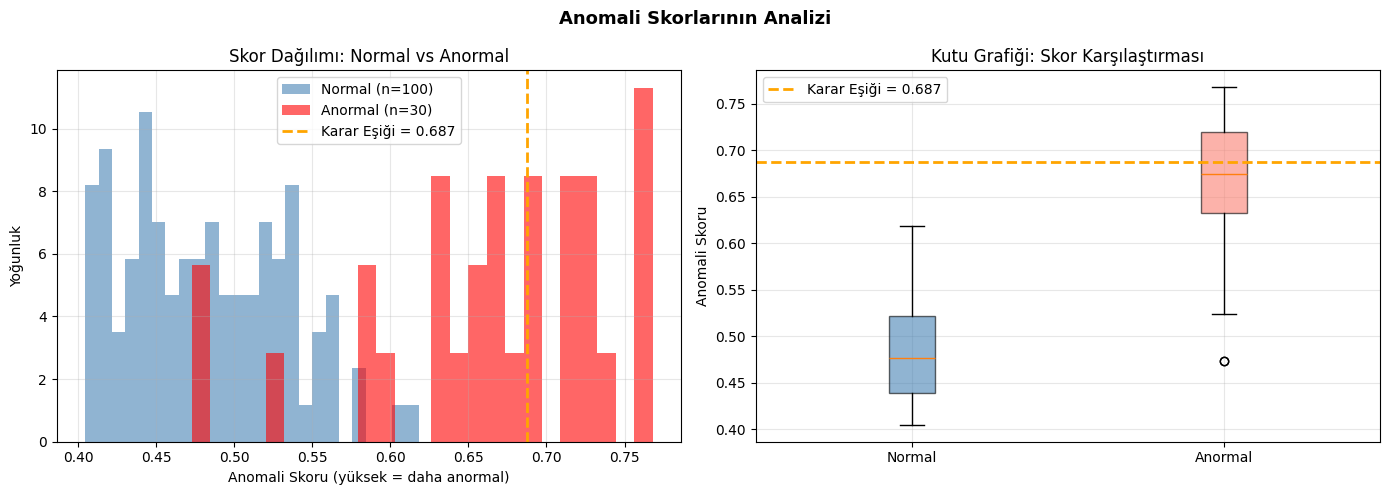

📸 skor_dagilimi.png kaydedildi

Ortalama Skor — Normal: 0.4825 | Anormal: 0.6662
Karar eşiği: 0.6874  →  bu eşiğin üstü anormal sayılır


In [8]:
# Normal ve anormal noktaların skorlarını ayır
scores_normal  = anomaly_scores_pos[y_true ==  1]  # normal noktaların skorları
scores_anomaly = anomaly_scores_pos[y_true == -1]  # anormal noktaların skorları

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Anomali Skorlarının Analizi', fontsize=13, fontweight='bold')

# ── Sol: Histogram ────────────────────────────────────────────────────────
ax = axes[0]
# bins=25: skoru 25 aralığa böl
# alpha=0.6: yarı saydam (üst üste gelen bölgeler görülsün)
ax.hist(scores_normal, bins=25, alpha=0.6, color='steelblue',
        label=f'Normal (n={len(scores_normal)})', density=True)
ax.hist(scores_anomaly, bins=25, alpha=0.6, color='red',
        label=f'Anormal (n={len(scores_anomaly)})', density=True)

# Karar eşiğini göster: contamination'a göre belirlenen kesim noktası
threshold = np.percentile(anomaly_scores_pos, (1 - model.contamination) * 100)
ax.axvline(x=threshold, color='orange', linestyle='--', linewidth=2,
           label=f'Karar Eşiği = {threshold:.3f}')

ax.set_xlabel('Anomali Skoru (yüksek = daha anormal)')
ax.set_ylabel('Yoğunluk')
ax.set_title('Skor Dağılımı: Normal vs Anormal')
ax.legend()
ax.grid(True, alpha=0.3)

# ── Sağ: Kutu Grafiği (Box Plot) ──────────────────────────────────────────
ax = axes[1]
# boxplot: ortanca, çeyrekler arası aralık ve aykırı değerleri gösterir
bp = ax.boxplot(
    [scores_normal, scores_anomaly],
    labels=['Normal', 'Anormal'],
    patch_artist=True,       # kutular renkli olsun
    notch=False,             # çentikli olmayan klasik kutu
    showfliers=True          # aykırı noktaları göster
)

# Kutu renklerini ayarla
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('salmon')
bp['boxes'][1].set_alpha(0.6)

ax.axhline(y=threshold, color='orange', linestyle='--', linewidth=2,
           label=f'Karar Eşiği = {threshold:.3f}')
ax.set_ylabel('Anomali Skoru')
ax.set_title('Kutu Grafiği: Skor Karşılaştırması')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('skor_dagilimi.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"📸 skor_dagilimi.png kaydedildi")
print(f"\nOrtalama Skor — Normal: {scores_normal.mean():.4f} | Anormal: {scores_anomaly.mean():.4f}")
print(f"Karar eşiği: {threshold:.4f}  →  bu eşiğin üstü anormal sayılır")

## 🗺️ 9. Karar Sınırı ve Tespit Sonuçları

/tmp/ipykernel_667/2806844475.py:80: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_667/2806844475.py:80: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_667/2806844475.py:81: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('isolation_forest_sonuclar.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_667/2806844475.py:81: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('isolation_forest_sonuclar.png', dpi=150, bbox_inches='tight')


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


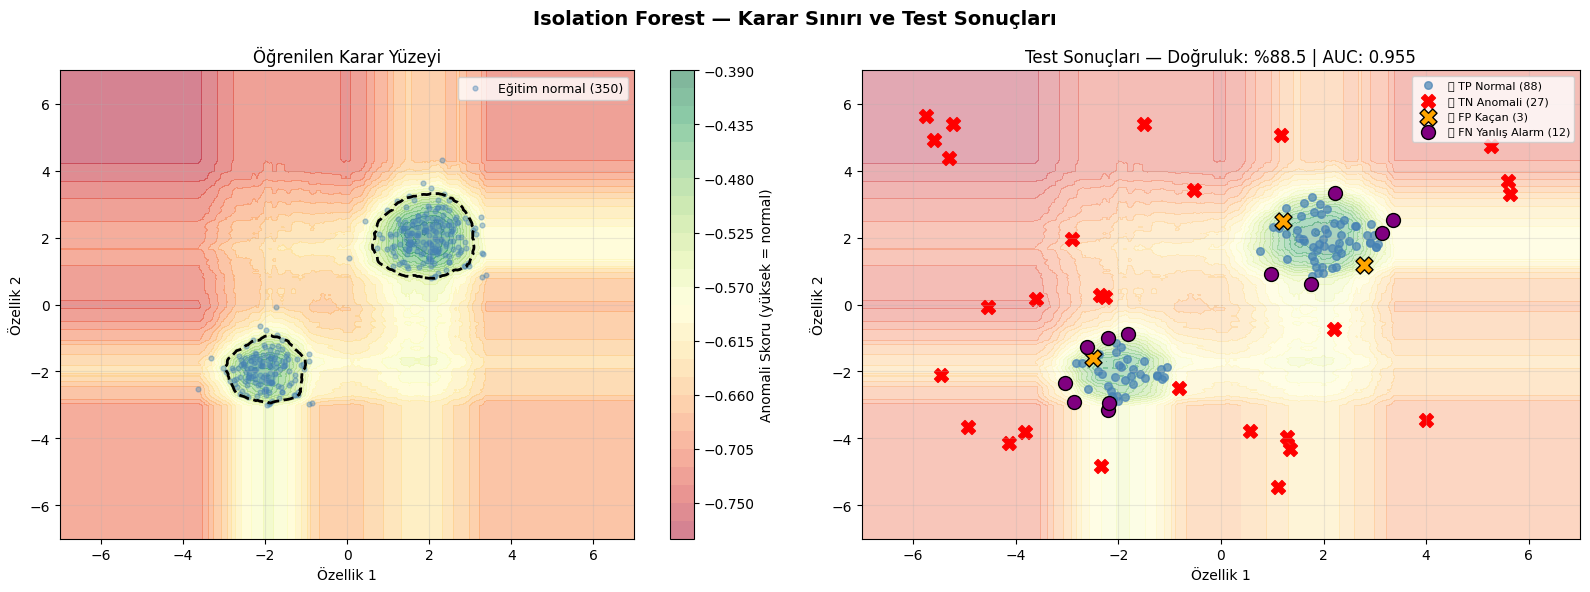

📸 isolation_forest_sonuclar.png kaydedildi


In [9]:
# ─── Karar Yüzeyi İçin Izgara ────────────────────────────────────────────
xx, yy = np.meshgrid(
    np.linspace(-7, 7, 300),  # x ekseni: -7'den +7'ye 300 nokta
    np.linspace(-7, 7, 300)   # y ekseni: -7'den +7'ye 300 nokta
)

# Izgara noktalarını (300×300) → (90000×2) matrise dönüştür
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Izgara noktalarını ölçekle (eğitimle aynı ölçeği kullan)
grid_scaled = scaler.transform(grid_points)

# Her ızgara noktası için anomali skoru hesapla
Z = model.score_samples(grid_scaled)   # ham skor
Z = Z.reshape(xx.shape)                # 300×300 matrisine yeniden şekillendir

# ─── Grafik ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Isolation Forest — Karar Sınırı ve Test Sonuçları',
             fontsize=14, fontweight='bold')

# ── Panel 1: Karar Yüzeyi ─────────────────────────────────────────────────
ax1 = axes[0]

# contourf: model skoruna göre arka planı renklendir
# score düşük (negatif) → anomali bölgesi (kırmızı)
# score yüksek (pozitif) → normal bölge (yeşil)
cf = ax1.contourf(xx, yy, Z, levels=25, cmap='RdYlGn', alpha=0.5)
plt.colorbar(cf, ax=ax1, label='Anomali Skoru (yüksek = normal)')

# Karar sınırı: contamination oranına göre belirlenen eşik değerindeki kontur
# score_samples() negatif değer döner; eşiğimiz anomali skorunun (1-contamination) yüzdeliği
decision_threshold = np.percentile(model.score_samples(X_train_scaled), model.contamination * 100)
ax1.contour(xx, yy, Z, levels=[decision_threshold],
    linewidths=2, colors='black', linestyles='--')

# Eğitim noktaları
ax1.scatter(X_train[:, 0], X_train[:, 1],
            c='steelblue', s=12, alpha=0.4, label=f'Eğitim normal ({len(X_train)})')

ax1.set_title('Öğrenilen Karar Yüzeyi')
ax1.set_xlabel('Özellik 1')
ax1.set_ylabel('Özellik 2')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25)
ax1.set_xlim(-7, 7)
ax1.set_ylim(-7, 7)

# ── Panel 2: Test Sonuçları ───────────────────────────────────────────────
ax2 = axes[1]

# Aynı arka planı çiz
ax2.contourf(xx, yy, Z, levels=25, cmap='RdYlGn', alpha=0.35)

# 4 kategori: TP, TN, FP, FN
mask_TP = (y_pred ==  1) & (y_true ==  1)  # Doğru normal
mask_TN = (y_pred == -1) & (y_true == -1)  # Doğru anomali
mask_FP = (y_pred ==  1) & (y_true == -1)  # Kaçan anomali
mask_FN = (y_pred == -1) & (y_true ==  1)  # Yanlış alarm

ax2.scatter(X_test[mask_TP, 0], X_test[mask_TP, 1],
            c='steelblue', s=30, alpha=0.7, label=f'✅ TP Normal ({mask_TP.sum()})')
ax2.scatter(X_test[mask_TN, 0], X_test[mask_TN, 1],
            c='red', marker='X', s=100, label=f'✅ TN Anomali ({mask_TN.sum()})')
ax2.scatter(X_test[mask_FP, 0], X_test[mask_FP, 1],
            c='orange', marker='X', s=150, edgecolors='black',
            label=f'❌ FP Kaçan ({mask_FP.sum()})', zorder=6)
ax2.scatter(X_test[mask_FN, 0], X_test[mask_FN, 1],
            c='purple', marker='o', s=100, edgecolors='black',
            label=f'❌ FN Yanlış Alarm ({mask_FN.sum()})', zorder=6)

ax2.set_title(f'Test Sonuçları — Doğruluk: %{accuracy:.1f} | AUC: {auc:.3f}')
ax2.set_xlabel('Özellik 1')
ax2.set_ylabel('Özellik 2')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.25)
ax2.set_xlim(-7, 7)
ax2.set_ylim(-7, 7)

plt.tight_layout()
plt.savefig('isolation_forest_sonuclar.png', dpi=150, bbox_inches='tight')
plt.show()
print("📸 isolation_forest_sonuclar.png kaydedildi")

## 🔬 10. Contamination Parametresinin Etkisi

`contamination`: verideki beklenen anomali oranı tahmini.  
Bu değer karar eşiğini (threshold) doğrudan etkiler:
- Çok düşük → az şey anomali sayılır → yüksek FP riski  
- Çok yüksek → çok şey anomali sayılır → yüksek FN riski

In [10]:
# Test edilecek contamination değerleri
contamination_values = [0.05, 0.10, 0.15, 0.20, 0.30]

results_cont = []

for cont in contamination_values:
    # Her contamination değeri için model oluştur ve eğit
    m = IsolationForest(
        n_estimators=200,
        contamination=cont,
        random_state=42
    )
    m.fit(X_train_scaled)
    preds = m.predict(X_test_scaled)
    
    # Metrikleri hesapla
    tp = ((preds ==  1) & (y_true ==  1)).sum()
    tn = ((preds == -1) & (y_true == -1)).sum()
    fp = ((preds ==  1) & (y_true == -1)).sum()
    fn = ((preds == -1) & (y_true ==  1)).sum()
    acc = (preds == y_true).mean() * 100
    rec = tn / (tn + fn) * 100 if (tn + fn) > 0 else 0  # anomali recall
    
    results_cont.append({
        'cont': cont, 'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'Acc': acc, 'Recall': rec
    })

# Tablo yazdır
print("┌────────────┬──────┬──────┬──────┬──────┬──────────┬────────────────┐")
print("│ contaminat │  TP  │  TN  │  FP  │  FN  │ Doğruluk │ Anomali Recall │")
print("├────────────┼──────┼──────┼──────┼──────┼──────────┼────────────────┤")
for r in results_cont:
    marker = " ◀" if abs(r['cont'] - 0.10) < 0.001 else "  "
    print(f"│    {r['cont']:.2f}    │ {r['TP']:4d} │ {r['TN']:4d} │ {r['FP']:4d} │ {r['FN']:4d} │  %{r['Acc']:5.1f}   │    %{r['Recall']:5.1f}       │{marker}")
print("└────────────┴──────┴──────┴──────┴──────┴──────────┴────────────────┘")
print("\n◀ Seçilen değer | TP=Doğru Normal | TN=Doğru Anomali | FP=Kaçan | FN=Yanlış Alarm")

┌────────────┬──────┬──────┬──────┬──────┬──────────┬────────────────┐
│ contaminat │  TP  │  TN  │  FP  │  FN  │ Doğruluk │ Anomali Recall │
├────────────┼──────┼──────┼──────┼──────┼──────────┼────────────────┤
│    0.05    │   96 │   27 │    3 │    4 │  % 94.6   │    % 87.1       │  
│    0.10    │   88 │   27 │    3 │   12 │  % 88.5   │    % 69.2       │ ◀
│    0.15    │   78 │   27 │    3 │   22 │  % 80.8   │    % 55.1       │  
│    0.20    │   68 │   28 │    2 │   32 │  % 73.8   │    % 46.7       │  
│    0.30    │   51 │   28 │    2 │   49 │  % 60.8   │    % 36.4       │  
└────────────┴──────┴──────┴──────┴──────┴──────────┴────────────────┘

◀ Seçilen değer | TP=Doğru Normal | TN=Doğru Anomali | FP=Kaçan | FN=Yanlış Alarm


## 🌲 11. Isolation Forest vs One-Class SVM Karşılaştırması

Her iki modeli aynı veri üzerinde çalıştırıp karar sınırlarını karşılaştıralım.

/tmp/ipykernel_667/2132203044.py:58: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_667/2132203044.py:58: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_667/2132203044.py:59: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('model_karsilastirma.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_667/2132203044.py:59: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('model_karsilastirma.png', dpi=150, bbox_inches='tight')


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


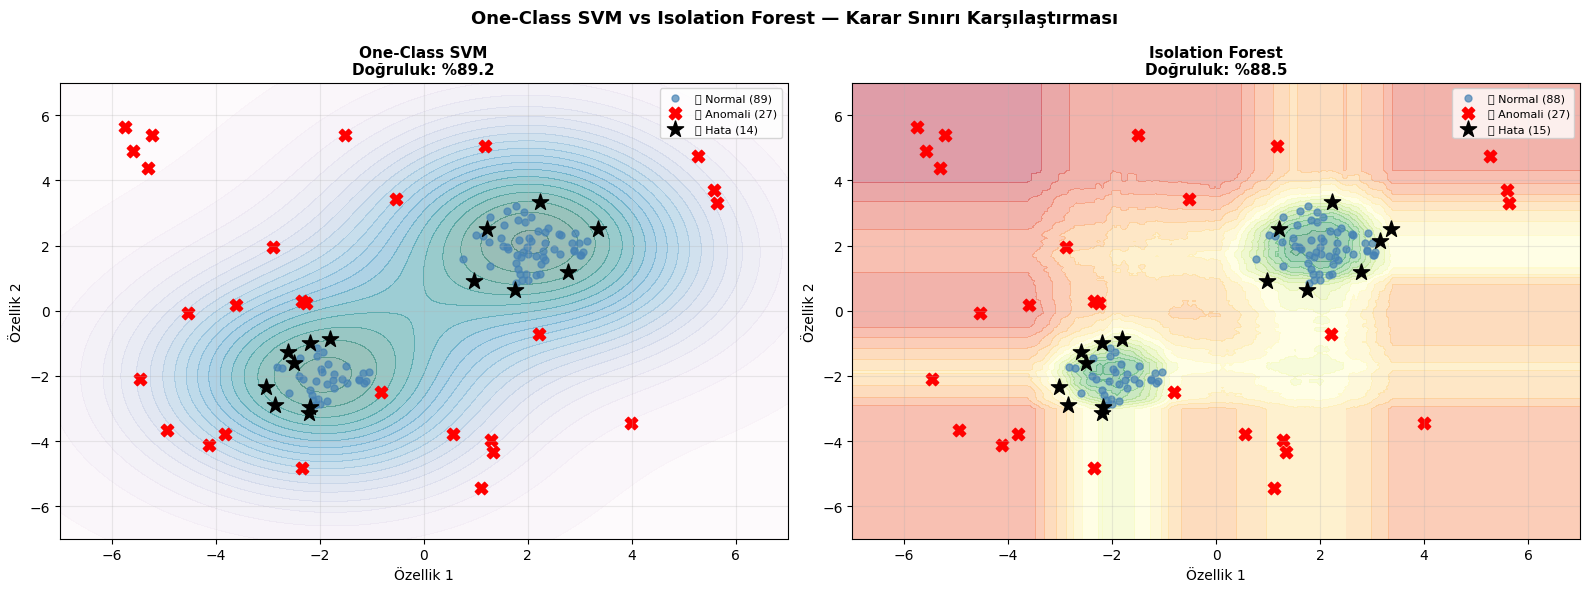

📸 model_karsilastirma.png kaydedildi

One-Class SVM  Doğruluk: %89.2
Isolation Forest Doğruluk: %88.5


In [11]:
from sklearn.svm import OneClassSVM

# ─── İki modeli de eğit ───────────────────────────────────────────────────
# One-Class SVM
ocsvm = OneClassSVM(kernel='rbf', nu=0.10, gamma='scale')
ocsvm.fit(X_train_scaled)
pred_svm = ocsvm.predict(X_test_scaled)
acc_svm  = (pred_svm == y_true).mean() * 100

# Isolation Forest
iforest = IsolationForest(n_estimators=200, contamination=0.10, random_state=42)
iforest.fit(X_train_scaled)
pred_if  = iforest.predict(X_test_scaled)
acc_if   = (pred_if == y_true).mean() * 100

# ─── Karar yüzeylerini hesapla ────────────────────────────────────────────
Z_svm = ocsvm.decision_function(grid_scaled).reshape(xx.shape)
Z_if  = iforest.score_samples(grid_scaled).reshape(xx.shape)

# ─── Grafik ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('One-Class SVM vs Isolation Forest — Karar Sınırı Karşılaştırması',
             fontsize=13, fontweight='bold')

models_data = [
    ('One-Class SVM', Z_svm, pred_svm, acc_svm, 'PuBuGn'),
    ('Isolation Forest', Z_if, pred_if, acc_if, 'RdYlGn'),
]

for ax, (name, Z_val, preds, acc_val, cmap) in zip(axes, models_data):
    # Arka plan renk haritası
    ax.contourf(xx, yy, Z_val, levels=20, cmap=cmap, alpha=0.4)
    
    # Test noktaları: doğru/yanlış tahminlere göre renk
    correct = preds == y_true
    wrong   = ~correct
    
    # Doğru tahmin edilen normal noktalar
    mask = correct & (y_true ==  1)
    ax.scatter(X_test[mask, 0], X_test[mask, 1],
               c='steelblue', s=25, alpha=0.7, label=f'✅ Normal ({mask.sum()})')
    # Doğru tahmin edilen anormal noktalar
    mask = correct & (y_true == -1)
    ax.scatter(X_test[mask, 0], X_test[mask, 1],
               c='red', marker='X', s=80, label=f'✅ Anomali ({mask.sum()})')
    # Yanlış tahminler
    ax.scatter(X_test[wrong, 0], X_test[wrong, 1],
               c='black', marker='*', s=150, label=f'❌ Hata ({wrong.sum()})', zorder=6)
    
    ax.set_title(f'{name}\nDoğruluk: %{acc_val:.1f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Özellik 1')
    ax.set_ylabel('Özellik 2')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)
    ax.set_xlim(-7, 7)
    ax.set_ylim(-7, 7)

plt.tight_layout()
plt.savefig('model_karsilastirma.png', dpi=150, bbox_inches='tight')
plt.show()
print("📸 model_karsilastirma.png kaydedildi")

print(f"\nOne-Class SVM  Doğruluk: %{acc_svm:.1f}")
print(f"Isolation Forest Doğruluk: %{acc_if:.1f}")

## 📋 12. Özet ve Sonuçlar

---

### 🧠 Isolation Forest'in Çalışma Mantığı

```
Normal nokta:   ●●●●●●●   → çok bölme gerekli → derin ağaç → yüksek skor → inlier  (+1)
Anormal nokta:  ●          → az bölme yeterli  → sığ ağaç  → düşük skor → outlier (-1)
```

### ⚖️ One-Class SVM vs Isolation Forest

| Özellik | One-Class SVM | Isolation Forest |
|---|---|---|
| **Yaklaşım** | Kernel tabanlı sınır | Ağaç tabanlı izolasyon |
| **Hız** | Yavaş (büyük veri) | Hızlı (lineer ölçeklenir) |
| **Ölçekleme** | Zorunlu | Önerilir |
| **Çok küme** | Zor | Kolay |
| **Anomali skoru** | decision_function | score_samples |
| **Ana parametre** | `nu`, `gamma` | `contamination`, `n_estimators` |

### ✅ Isolation Forest'in Avantajları
- **Büyük veri** ile ölçeklenir (O(n log n))
- **Çok sayıda küme** içeren veriyle iyi çalışır
- Anomali oranı bilinmiyorsa `contamination='auto'` kullanılabilir
- Paralel eğitim (`n_jobs=-1`) desteği var

### ⚠️ Sınırlamalar
- Düşük boyutlu veride sınırlar daha kaba çizilir
- "Küme anomalileri" (birlikte gelen anormal gruplar) zor tespit edilir
- `contamination` seçimi domain bilgisi gerektirir

In [12]:
# Final Özet
print("=" * 55)
print("        ISOLATION FOREST — SONUÇ ÖZETİ")
print("=" * 55)
print(f"  Eğitim seti      : {len(X_train)} normal nokta (2 küme)")
print(f"  Test seti        : {len(X_test)} nokta ({len(X_test_normal)} normal + {len(X_test_anomaly)} anormal)")
print(f"  Ağaç sayısı      : {model.n_estimators}")
print(f"  Contamination    : {model.contamination}")
print(f"  Genel Doğruluk   : %{accuracy:.1f}")
print(f"  ROC-AUC Skoru    : {auc:.4f}")
print(f"  Anomali Recall   : %{recall*100:.1f}  ({TN}/{len(X_test_anomaly)} anomali tespit edildi)")
print("=" * 55)
print("\n✅ Notebook başarıyla tamamlandı!")

        ISOLATION FOREST — SONUÇ ÖZETİ
  Eğitim seti      : 350 normal nokta (2 küme)
  Test seti        : 130 nokta (100 normal + 30 anormal)
  Ağaç sayısı      : 200
  Contamination    : 0.1
  Genel Doğruluk   : %88.5
  ROC-AUC Skoru    : 0.9547
  Anomali Recall   : %69.2  (27/30 anomali tespit edildi)

✅ Notebook başarıyla tamamlandı!
